Paquetes necesarios

In [1]:
import cv2  
import numpy as np
import matplotlib.pyplot as plt

**TAREA 1**: Sin herramientas de IA, crea una imagen, p.e. de 800x800 píxeles, con la textura del tablero de ajedrez.
Una vez resuelto de forma manual, resuelve la misma tarea usando un asistente de IA de tu elección (Claude, ChatGPT, Copilot, etc.). Compara ambas versiones en el informe de la práctica.

Versión Manual

(800, 800, 3)


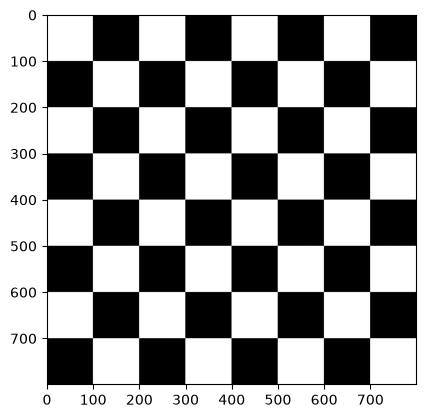

In [2]:
#Crea una imagen con tres planos
color_img = np.zeros((800,800,3), dtype = np.uint8)

for i in range(8):
    if i%2 == 0:
        for j in range(0,8,2):
                    color_img[i*100:(i+1)*100, j*100:(j+1)*100] = 255
    else:
        for j in range(1,8,2):
                    color_img[i*100:(i+1)*100, j*100:(j+1)*100] = 255                
        
#Dimensiones
print(color_img.shape)

#Visualiza con matplotlib (sin especificar el mapa de color gris)
plt.imshow(color_img) 

plt.show()


Versión IA

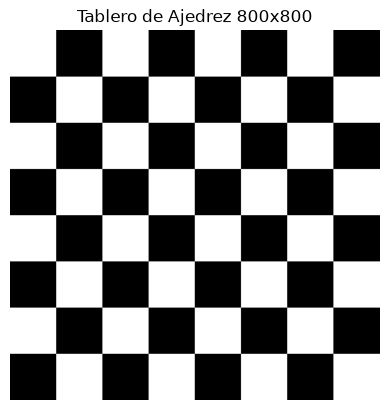

In [ ]:


# 1. Definir dimensiones
img_size = 800
casillas = 8
tamano_casilla = img_size // casillas  # 100 píxeles por casilla

# 2. Crear un array de 800x800 lleno de ceros (color negro)
tablero = np.zeros((img_size, img_size), dtype=np.uint8)

# 3. Dibujar los cuadrados blancos
for fila in range(casillas):
    for col in range(casillas):
        # En un tablero, las casillas blancas ocurren cuando la suma de fila y columna es par
        if (fila + col) % 2 == 0:
            # Calcular las coordenadas de inicio y fin para cada casilla
            y_inicio = fila * tamano_casilla
            y_fin = y_inicio + tamano_casilla
            x_inicio = col * tamano_casilla
            x_fin = x_inicio + tamano_casilla
            
            # Asignar el valor 255 (blanco) a esa región del array
            tablero[y_inicio:y_fin, x_inicio:x_fin] = 255

# 4. Mostrar la imagen usando matplotlib
plt.imshow(tablero, cmap='gray')
plt.title('Tablero de Ajedrez 800x800')
plt.axis('off') # Ocultar los ejes numéricos
plt.show()

# Opcional: Guardar la imagen con OpenCV si lo necesitas
# cv2.imwrite('tablero_ajedrez.png', tablero)

**Comparación IA vs Manual**

En la estructura de la IA usa crea una matriz 2D (escala de grises) y la versión manual 3D que para hacer un tablero de ajedrez puede ser mejor la versión de la IA ya que no se van a usar colores. En la lógica podemos observar que en la version IA que itera sobre las 64 casillas ```python (fila + columna) % 2 == 0``` para encender las blancas y en la versión manual se separan filas pares e impares y se usa un bucle con saltos para pintar las casillas blancas en la matriz principalmente negra.


**Ampliación**: Mapa del mítico juego Pacman

<details>
<summary><b>Conversación con IA</b></summary>

<br>

**Prompt:**  
opencv python documentation

**IA:**  
La documentación oficial de OpenCV para Python está integrada directamente dentro del sitio web principal de la biblioteca. A continuación se detallan los recursos clave y la estructura para consultarla:

### 📌 Canales Oficiales y Enlaces de Interés

* **[Sitio Web Oficial de Documentación de OpenCV](https://docs.opencv.org/):** Página principal. Permite seleccionar la versión de OpenCV utilizada (por ejemplo, 4.x) para acceder a los módulos y funciones correspondientes.
* **[Sección de Tutoriales de OpenCV-Python](https://docs.opencv.org/4.x/d6/d00/tutorial_py_root.html):** Guías paso a paso para Python, desde operaciones básicas de dibujo y procesamiento hasta técnicas de visión artificial.
* **[Repositorio en PyPI (opencv-python)](https://pypi.org/project/opencv-python/):** Información de instalación del paquete oficial y sus variantes (`opencv-python`, `opencv-contrib-python`, etc.).

---

### 💡 Lectura de Firmas de Funciones para Python

En la referencia de la API, las firmas para Python se indican bajo la especificación de C++:

#### Firma en C++
```cpp
void cv::imshow(const String &winname, InputArray mat)
```

#### Firma en Python (módulo cv2)
```python
cv.imshow(winname, mat)
```

---

### 🛠️ Guía Rápida de Inicio con Python

1. **Instalación estándar:**
   ```bash
   pip install opencv-python
   ```

2. **Carga y visualización básica:**
   ```python
   import cv2 as cv
   import sys

   img = cv.imread("ruta_de_tu_imagen.jpg")
   if img is None:
       sys.exit("No se pudo leer la imagen.")

   cv.imshow("Ventana de Visualización", img)
   cv.waitKey(0)
   cv.destroyAllWindows()
   ```

---

**Fuentes:**  
[1] https://docs.opencv.org  
[2] https://pypi.org/project/opencv-python/  
[3] https://docs.opencv.org/4.x/d6/d00/tutorial_py_root.html  

---

**Prompt:**  
Según la documentación, dime las funciones necesarias para poder crear las figuras correspondientes a esta imagen de pacman para hacerlo manualmente.

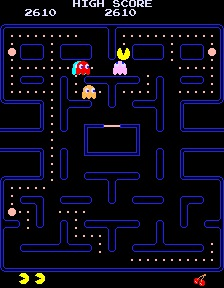

**IA:**  
Para representar los elementos visuales del escenario clásico de Pac-Man utilizando el módulo `imgproc` de OpenCV sobre una matriz inicializada con `np.zeros()`, se emplean las siguientes primitivas de dibujo:

### 1. El Laberinto (Muros y Líneas Azules)
* `cv2.rectangle(img, pt1, pt2, color, thickness)`: Para cajas cerradas (como la zona central de los fantasmas), indicando la esquina superior izquierda `pt1` e inferior derecha `pt2`.
* `cv2.line(img, pt1, pt2, color, thickness)`: Para tramos rectos de pasillos o divisiones simples.
* `cv2.ellipse(img, center, axes, angle, startAngle, endAngle, color, thickness)`: Para redondear esquinas o crear cápsulas en los extremos de los muros.

### 2. Pac-Man
* `cv2.ellipse(...)`: Permite dibujar el arco circular relleno ajustando `startAngle` y `endAngle` (por ejemplo, de 30° a 330°) para dejar libre el sector de la boca.

### 3. Fantasmas
* `cv2.circle(img, center, radius, color, thickness)`: Para la cabeza superior y los ojos/pupilas. Con `thickness=-1` queda relleno.
* `cv2.fillPoly(img, pts, color)`: Para delimitar el cuerpo y los picos inferiores mediante un conjunto de vértices poligonales.

### 4. Puntos y Pastillas de Poder
* `cv2.circle(img, center, radius, color, thickness)`: Con radio pequeño para los puntos regulares y radio mayor para las píldoras de las esquinas (`thickness=-1`).

### 5. Marcador y Texto
* `cv2.putText(img, text, org, fontFace, fontScale, color, thickness)`: Para renderizar puntuaciones y textos superiores con fuentes como `cv2.FONT_HERSHEY_PLAIN`.

---

### 🎨 Parámetro Clave de Documentación
Para cualquier figura geométrica cerrada, asignar `thickness=-1` hace que OpenCV rellene la figura de forma sólida en lugar de dibujar solo su contorno.

---

**Prompt:**  
Vale, dame un ejemplo sencillo para tener una idea

**IA:**  
A continuación se muestra un ejemplo mínimo que combina el dibujo de un muro, puntos de paso, una píldora de poder y a Pac-Man con la boca abierta:

```python
import cv2 as cv
import numpy as np

# 1. Crear lienzo negro (formato BGR nativo de OpenCV)
canvas = np.zeros((400, 400, 3), dtype="uint8")

AZUL = (255, 0, 0)
AMARILLO = (0, 255, 255)
BLANCO = (255, 255, 255)
ROSA = (255, 192, 203)

# 2. Muros y puntos
cv.rectangle(canvas, (50, 50), (350, 350), AZUL, thickness=3)
cv.circle(canvas, (100, 200), radius=3, color=BLANCO, thickness=-1)
cv.circle(canvas, (150, 200), radius=3, color=BLANCO, thickness=-1)
cv.circle(canvas, (75, 75), radius=10, color=ROSA, thickness=-1)

# 3. Pac-Man con elipse
cv.ellipse(canvas, (200, 200), (25, 25), 0, 30, 330, AMARILLO, thickness=-1)

# 4. Texto
cv.putText(canvas, "SCORE 2610", (110, 35), cv.FONT_HERSHEY_PLAIN, 1.5, BLANCO, thickness=2)

# 5. Visualización
cv.imshow("Mini Pac-Man OpenCV", canvas)
cv.waitKey(0)
cv.destroyAllWindows()
```

### 🔍 Consideraciones del Código
* **Apertura de boca:** El intervalo angular de 30° a 330° en sentido horario genera el sector vacío frontal característico.
* **Sistema de coordenadas:** El origen `(0, 0)` se ubica en la esquina superior izquierda (eje X hacia la derecha, eje Y hacia abajo).

</details>

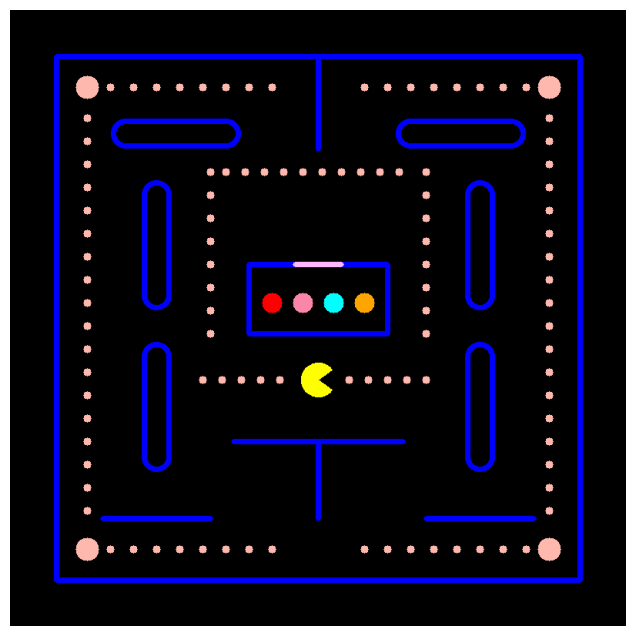

In [9]:

# Constantes de configuración y paleta RGB
ANCHO, ALTO = 800, 800

COLOR_MURO = (0, 0, 255)
COLOR_PUNTO = (255, 184, 174)
COLOR_PACMAN = (255, 255, 0)
COLOR_PUERTA = (255, 184, 255)

COLOR_BLINKY = (255, 0, 0)
COLOR_PINKY = (252, 134, 170)
COLOR_INKY = (0, 255, 255)
COLOR_CLYDE = (255, 165, 0)


def dibujar_tablero(img):
    """Dibuja el marco perimetral, la casa de fantasmas y los muros interiores."""
    # Marco exterior
    cv2.rectangle(img, (60, 60), (740, 740), COLOR_MURO, 5)

    # Casa central de los fantasmas
    cv2.rectangle(img, (310, 330), (490, 420), COLOR_MURO, 5)
    cv2.line(img, (370, 330), (430, 330), COLOR_PUERTA, 5)

    # Divisor central superior
    cv2.line(img, (400, 60), (400, 180), COLOR_MURO, 6)

    # Cápsulas superiores horizontales
    cv2.ellipse(img, (150, 160), (16, 16), 0, 90, 270, COLOR_MURO, 5)
    cv2.ellipse(img, (280, 160), (16, 16), 0, 270, 450, COLOR_MURO, 5)
    cv2.line(img, (150, 144), (280, 144), COLOR_MURO, 5)
    cv2.line(img, (150, 176), (280, 176), COLOR_MURO, 5)

    cv2.ellipse(img, (520, 160), (16, 16), 0, 90, 270, COLOR_MURO, 5)
    cv2.ellipse(img, (650, 160), (16, 16), 0, 270, 450, COLOR_MURO, 5)
    cv2.line(img, (520, 144), (650, 144), COLOR_MURO, 5)
    cv2.line(img, (520, 176), (650, 176), COLOR_MURO, 5)

    # Cápsulas superiores verticales
    cv2.ellipse(img, (190, 240), (16, 16), 0, 180, 360, COLOR_MURO, 5)
    cv2.ellipse(img, (190, 370), (16, 16), 0, 0, 180, COLOR_MURO, 5)
    cv2.line(img, (174, 240), (174, 370), COLOR_MURO, 5)
    cv2.line(img, (206, 240), (206, 370), COLOR_MURO, 5)

    cv2.ellipse(img, (610, 240), (16, 16), 0, 180, 360, COLOR_MURO, 5)
    cv2.ellipse(img, (610, 370), (16, 16), 0, 0, 180, COLOR_MURO, 5)
    cv2.line(img, (594, 240), (594, 370), COLOR_MURO, 5)
    cv2.line(img, (626, 240), (626, 370), COLOR_MURO, 5)

    # Cápsulas inferiores verticales
    cv2.ellipse(img, (190, 450), (16, 16), 0, 180, 360, COLOR_MURO, 5)
    cv2.ellipse(img, (190, 580), (16, 16), 0, 0, 180, COLOR_MURO, 5)
    cv2.line(img, (174, 450), (174, 580), COLOR_MURO, 5)
    cv2.line(img, (206, 450), (206, 580), COLOR_MURO, 5)

    cv2.ellipse(img, (610, 450), (16, 16), 0, 180, 360, COLOR_MURO, 5)
    cv2.ellipse(img, (610, 580), (16, 16), 0, 0, 180, COLOR_MURO, 5)
    cv2.line(img, (594, 450), (594, 580), COLOR_MURO, 5)
    cv2.line(img, (626, 450), (626, 580), COLOR_MURO, 5)

    # Estructura en T y barras inferiores
    cv2.line(img, (290, 560), (510, 560), COLOR_MURO, 6)
    cv2.line(img, (400, 560), (400, 660), COLOR_MURO, 6)
    cv2.line(img, (120, 660), (260, 660), COLOR_MURO, 6)
    cv2.line(img, (540, 660), (680, 660), COLOR_MURO, 6)


def dibujar_fantasmas(img):
    """Ubica los 4 fantasmas dentro de la casa central."""
    cv2.circle(img, (340, 380), 13, COLOR_BLINKY, -1)
    cv2.circle(img, (380, 380), 13, COLOR_PINKY, -1)
    cv2.circle(img, (420, 380), 13, COLOR_INKY, -1)
    cv2.circle(img, (460, 380), 13, COLOR_CLYDE, -1)


def dibujar_puntos(img):
    """Traza los caminos de puntos y las píldoras de poder."""
    # Anillos perimetrales horizontales (Y=100 e Y=700)
    for x in range(130, 370, 30):
        cv2.circle(img, (x, 100), 5, COLOR_PUNTO, -1)
        cv2.circle(img, (800 - x, 100), 5, COLOR_PUNTO, -1)
        cv2.circle(img, (x, 700), 5, COLOR_PUNTO, -1)
        cv2.circle(img, (800 - x, 700), 5, COLOR_PUNTO, -1)

    # Columnas laterales exteriores (X=100 y X=700)
    for y in range(140, 670, 30):
        cv2.circle(img, (100, y), 5, COLOR_PUNTO, -1)
        cv2.circle(img, (700, y), 5, COLOR_PUNTO, -1)

    # Pasillo horizontal central (Y=480)
    for x in range(250, 360, 25):
        cv2.circle(img, (x, 480), 5, COLOR_PUNTO, -1)
    for x in range(440, 560, 25):
        cv2.circle(img, (x, 480), 5, COLOR_PUNTO, -1)

    # Columnas intermedias (X=260 y X=540)
    for y in range(210, 450, 30):
        cv2.circle(img, (260, y), 5, COLOR_PUNTO, -1)
        cv2.circle(img, (540, y), 5, COLOR_PUNTO, -1)

    # Conexión horizontal superior interior (Y=210)
    for x in range(280, 530, 25):
        cv2.circle(img, (x, 210), 5, COLOR_PUNTO, -1)

    # 4 Píldoras de poder
    cv2.circle(img, (100, 100), 15, COLOR_PUNTO, -1)
    cv2.circle(img, (700, 100), 15, COLOR_PUNTO, -1)
    cv2.circle(img, (100, 700), 15, COLOR_PUNTO, -1)
    cv2.circle(img, (700, 700), 15, COLOR_PUNTO, -1)


def dibujar_pacman(img, pos=(400, 480), r=22):
    """Dibuja a Pac-Man orientado a la derecha con sector abierto."""
    cv2.ellipse(img, pos, (r, r), 0, 35, 325, COLOR_PACMAN, -1)


def crear_juego_pacman():
    """Inicializa el lienzo y coordina el renderizado completo."""
    lienzo = np.zeros((ALTO, ANCHO, 3), dtype=np.uint8)
    dibujar_tablero(lienzo)
    dibujar_fantasmas(lienzo)
    dibujar_puntos(lienzo)
    dibujar_pacman(lienzo)
    return lienzo


def main():
    escenario = crear_juego_pacman()
    plt.figure(figsize=(8, 8))
    plt.imshow(escenario)
    plt.axis("off")
    plt.show()


if __name__ == "__main__":
    main()

**TAREA 2**: Crear una imagen estilo Mondrian (un ejemplo https://www3.gobiernodecanarias.org/medusa/ecoescuela/sa/2017/04/17/descubriendo-a-mondrian/) con las funciones de dibujo de OpenCV.
No hagas uso de herramientas de IA, parte del ejemplo anterior.

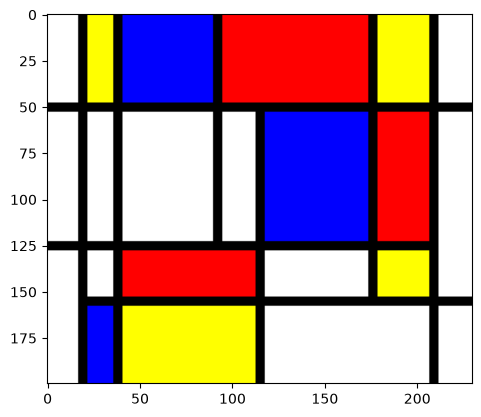

True

In [4]:
#Crea una imagen con tres planos
ancho = 230
alto = 200
color_img = np.zeros((alto, ancho, 3), dtype = np.uint8)

# Todo blanco
color_img[:,:,:] = 255 

m = 3
# Cordenadas X
x1 = int(ancho/12)
x2 = int(ancho/6)
x3 = int(ancho/2.5)
x4 = int(ancho/2)
x5 = int(ancho/1.3)
x6 = int(ancho/1.1)

# Cordenadas Y
y1 = 50
y2 = 125
y3 = 155

# Lineas negra vertical de grosor 3
cv2.line(color_img,(x1,0),(x1,alto),(0,0,0),m)
cv2.line(color_img,(x2,0),(x2,alto),(0,0,0),m)
cv2.line(color_img,(x3,0),(x3,y2),(0,0,0),m)
cv2.line(color_img,(x4,y1),(x4,alto),(0,0,0),m)
cv2.line(color_img,(x5,0),(x5,y3),(0,0,0),m)
cv2.line(color_img,(x6,0),(x6,alto),(0,0,0),m)


# Linea negra horizontal de grosor 3
cv2.line(color_img,(0,y1),(ancho,y1),(0,0,0),m)
cv2.line(color_img,(0,y2),(x6,y2),(0,0,0),m)
cv2.line(color_img,(x1,y3),(ancho,y3),(0,0,0),m)


# Rectángulos amarillos
cv2.rectangle(color_img, (x1+m, 0), (x2-m, y1-m), (255,255,0), -1)
cv2.rectangle(color_img, (x5+m, 0), (x6-m, y1-m), (255,255,0), -1)
cv2.rectangle(color_img, (x5+m, y2+m), (x6-m, y3-m), (255,255,0), -1)
cv2.rectangle(color_img, (x2+m, y3+m), (x4-m, alto), (255,255,0), -1)

# Rectángulos azules
cv2.rectangle(color_img, (x2+m, 0), (x3-m, y1-m), (0,0,255), -1)
cv2.rectangle(color_img, (x4+m, y1+m), (x5-m, y2-m), (0,0,255), -1)
cv2.rectangle(color_img, (x1+m, y3+m), (x2-m, alto), (0,0,255), -1)

# Rectángulos rojos
cv2.rectangle(color_img, (x3+m, 0), (x5-m, y1-m), (255,0,0), -1)
cv2.rectangle(color_img, (x5+m, y1+m), (x6-m, y2-m), (255,0,0), -1)
cv2.rectangle(color_img, (x2+m, y2+m), (x4-m, y3-m), (255,0,0), -1)


#Visualiza sin especificar el mapa de color gris
plt.imshow(color_img) 
plt.show()

#Salva la imagen resultante a disco
cv2.imwrite('imagen.jpg', color_img)

**TAREA 3**:
Pintar círculos en las posiciones del píxel más claro y oscuro de cada fotograma captado por la cámara. ¿Funciona de forma fluida o a saltos? En el segundo caso, ¿podrías acelerarlo?
Si haces uso de herramientas de IA, incluye la conversación.




<details>
<summary><b>Conversación con IA</b></summary>

**Prompt:** 
Tarea: Pintar círculos en las posiciones del píxel más claro y oscuro de cada fotograma captado por la cámara. ¿Funciona de forma fluida o a saltos? En el segundo caso, ¿podrías acelerarlo?

Si haces uso de herramientas de IA, incluye la conversación.

Recorrí la matriz de pixeles con un doble bucle pero como pone el enunciado no funciona de forma fluida debido a toda la carga computacional que tienen los bucles hay alaguna función que facilite esto ? No me des codigo dime solo si existe alguna forma y cual.

**IA:** 
¡Hola! Es completamente normal lo que te está pasando. Leer la información de cada píxel de una imagen usando un doble bucle (uno para el ancho y otro para el alto) en tiempo real exige muchísimo procesamiento, por eso el video se ve a saltos.

Sí, existen formas de acelerarlo drásticamente, pero la herramienta o función específica depende del lenguaje y la librería que estés utilizando (asumo que podrías estar usando OpenCV, Processing, p5.js o Python).

Aquí tienes las soluciones según tu entorno:

1. Si usas librerías de Visión Artificial (OpenCV / Python)
Si estás programando con OpenCV, sí existe una función específica que hace exactamente esto en una fracción de milisegundo: se llama minMaxLoc. Esta función escanea la imagen y te devuelve de golpe los valores mínimo y máximo junto con sus coordenadas exactas (x, y). Al estar programada internamente en C++, está hiperoptimizada y elimina la necesidad de hacer bucles en tu código.

Si usas Python puro con NumPy, puedes usar las funciones argmin y argmax para encontrar rápidamente los índices de los valores más oscuros y claros sin escribir tú el bucle.

2. Si usas entornos de arte generativo (Processing / p5.js)
En estos entornos no hay una sola función mágica que te dé las coordenadas, pero la forma de hacer que vaya a 60 FPS (fluido) consiste en cambiar la arquitectura de tu bucle:

Pasar a un bucle unidimensional (1D): En lugar de usar un doble bucle (x, y), debes acceder al arreglo de píxeles como una única lista plana. Un solo bucle que recorra todos los píxeles de principio a fin es computacionalmente mucho más rápido. Luego, usando una sencilla fórmula matemática, puedes deducir la coordenada (x, y) a partir de la posición de ese píxel en la lista.

Evitar funciones de cálculo de color: A veces el culpable de la lentitud no es solo el bucle, sino calcular el "brillo" dentro de él. Si usas funciones integradas para extraer los canales de color, ralentizarás el proceso. La alternativa rápida es leer los valores del arreglo directamente o usar operaciones a nivel de bits (bitwise).

La clave de la optimización en video no es solo evitar los bucles, sino delegar el trabajo pesado a funciones nativas de bajo nivel o simplificar cómo la memoria lee los datos.

</details>


In [14]:
# Camara web
vid = cv2.VideoCapture(0)
  
while(True):      
    # fotograma a fotograma
    ret, frame = vid.read()

    # Hay nuevo fotograma
    if ret:
        frame_gris = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        # Inicializo variables para el pixel mas claro y el mas oscuro
        maximo = -1
        minimo = 256
        max_loc, min_loc = (0,0), (0,0)
        for i in range(frame_gris.shape[0]):
            for j in range(frame_gris.shape[1]):

                # Avergiguar el pixel mas claro y el mas oscuro
                pixel = frame_gris[i, j]
                
                if pixel > maximo:
                    maximo = pixel
                    max_loc = (j, i)
                if pixel < minimo:
                    minimo = pixel
                    min_loc = (j, i)

        # Dibujo los círculos
        cv2.circle(frame, max_loc, 15, (255, 255, 0), 2) 
        cv2.circle(frame, min_loc, 15, (0, 0, 255), 2)

        # Muestra fotograma
        cv2.imshow('Vid', frame)

    
    # Detenemos pulsado ESC
    if cv2.waitKey(20) == 27:
        break
  
# Libera el objeto de captura
vid.release()
# Destruye ventanas
cv2.destroyAllWindows()

In [4]:
# Camara web
vid = cv2.VideoCapture(0)
  
while(True):      
    # fotograma a fotograma
    ret, frame = vid.read()
    # Hay nuevo fotograma
    if ret:  
        frame_gris = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        max_val, min_val, max_loc, min_loc = cv2.minMaxLoc(frame_gris)
        cv2.circle(frame, max_loc, 10, (0, 255, 0), 2) 
        cv2.circle(frame, min_loc, 10, (0, 0, 255), 2)
        # Muestra fotograma
        cv2.imshow('Vid', frame)

    
    # Detenemos pulsado ESC
    if cv2.waitKey(20) == 27:
        break
  
# Libera el objeto de captura
vid.release()
# Destruye ventanas
cv2.destroyAllWindows()

**TAREA 4**: Llevar a cabo una propuesta propia de pop art.
Incluye fuentes consultadas. 
Si haces uso de herramientas de IA, incluye la conversación.


<details>
<summary><b>Conversación con IA - Tarea 4: Efecto Pop Art con Webcam</b></summary>

<br>

**Prompt:**  
Buenas, estoy haciendo la tarea 4 de la práctica de Visión por Computador (el efecto Pop Art estilo Andy Warhol con la webcam). En el cuaderno base viene un ejemplo donde divide la pantalla en 4 cuadrantes haciendo rebanado manual (`collage = np.zeros(...)` y `tl = collage[0:h, 0:w]`) y altera los canales restando valores a 255 (`255 - r`)[cite: 1]. El resultado queda algo apagado y no parece una serigrafía real. ¿Existe en OpenCV alguna función para aplicar paletas de colores llamativas sin tener que manipular los píxeles canal a canal a mano?

**IA:**  
Sí, la herramienta estándar en OpenCV para ese propósito es `cv2.applyColorMap()`. Permite reasignar los niveles de brillo a paletas de color predefinidas mediante tablas de consulta (*Look-Up Tables* o LUT).

Para conseguir el acabado de serigrafía o póster característico de Warhol, se recomienda:
1. **Reducción de resolución previa:** Redimensionar el fotograma con `cv2.resize()` para que el mosaico conjunto no desborde la pantalla[cite: 1].
2. **Paso a escala de grises:** Convertir a monocanal con `cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)`. De este modo, la función evalúa la luminancia pura (0 a 255) y proyecta colores planos y saturados, en lugar de teñir píxeles que ya tienen color BGR.
3. **Selección de mapas de color:** Emplear constantes como `cv2.COLORMAP_AUTUMN`, `cv2.COLORMAP_SPRING` o `cv2.COLORMAP_OCEAN`.
4. **Inversión puntual:** Usar `cv2.bitwise_not()` sobre la imagen en grises antes de aplicar el mapa para generar negativos de alto contraste.

---

**Prompt:**  
Vale, me queda claro lo de los mapas de color. Para montar el collage 2x2, en el ejemplo del cuaderno se crea un lienzo negro y se calculan las coordenadas de corte con índices tipo `collage[0:h, w:w+w]`. ¿Hay alguna forma más limpia y directa en NumPy para unir los 4 cuadrantes sin liarme calculando índices manuales?

**IA:**  
Se pueden utilizar las funciones de concatenación matricial de NumPy: `np.hstack()` (unión horizontal) y `np.vstack()` (unión vertical). 

Al recibir matrices con idénticas dimensiones y tipo de dato (`uint8`), NumPy las fusiona de forma vectorial sin necesidad de instanciar un lienzo vacío ni gestionar rangos de corte manualmente[cite: 1].

A continuación se presenta el código completo estructurado:

```python
import cv2
import numpy as np

# 1. Inicializar la captura de la webcam
vid = cv2.VideoCapture(0)

while True:
    ret, frame = vid.read()
    if not ret:
        break

    # 2. Redimensionar a la mitad para encajar el mosaico 2x2
    h, w = frame.shape[:2]
    small = cv2.resize(frame, (int(w / 2), int(h / 2)))

    # 3. Extraer luminancia para falso color
    gray = cv2.cvtColor(small, cv2.COLOR_BGR2GRAY)

    # 4. Generar los 4 cuadrantes con distintos tratamientos
    # Cuadrante 1: Paleta cálida (Otoño)
    q1 = cv2.applyColorMap(gray, cv2.COLORMAP_AUTUMN)

    # Cuadrante 2: Paleta fría invertida (Océano sobre negativo)
    q2 = cv2.applyColorMap(cv2.bitwise_not(gray), cv2.COLORMAP_OCEAN)

    # Cuadrante 3: Paleta primaveral
    q3 = cv2.applyColorMap(gray, cv2.COLORMAP_SPRING)

    # Cuadrante 4: Negativo fotográfico del fotograma original
    q4 = cv2.bitwise_not(small)

    # 5. Ensamblado del mosaico mediante concatenación de matrices
    fila_superior = np.hstack((q1, q2))
    fila_inferior = np.hstack((q3, q4))
    mosaico = np.vstack((fila_superior, fila_inferior))

    # 6. Mostrar resultado
    cv2.imshow("Andy Warhol Pop Art", mosaico)

    # Detener ejecución pulsando la tecla ESC (código ASCII 27)
    if cv2.waitKey(20) == 27:
        break

# Liberar dispositivo y cerrar ventana
vid.release()
cv2.destroyAllWindows()
```

---

### 🔍 Puntos Clave para la Defensa Oral

* **`cv2.applyColorMap` sobre escala de grises:** Al aplicarse sobre una imagen de un solo canal, cada valor de intensidad lumínica se traduce directamente a un tono RGB específico de la paleta, simulando el entintado de una serigrafía tradicional.
* **Operación `cv2.bitwise_not`:** Ejecuta una inversión bit a bit ($255 - \text{píxel}$) a bajo nivel de memoria, equivalente al negativo analógico.
* **Uso de `np.hstack` y `np.vstack` frente a *slicing*:** Elimina el cálculo propenso a errores de índices en matrices (`[0:h, w:w+w]`), garantizando coherencia dimensional en tiempo de ejecución[cite: 1].

</details>

In [7]:
vid = cv2.VideoCapture(0)

while True:      
    ret, frameIN = vid.read()
    if ret:
        # Cogemos solo la altura y anchura del frame
        h, w = frameIN.shape[:2]
        frame = cv2.resize(frameIN, (int(w/2), int(h/2)))

        # Cuadrante 1 Original
        q1 = frame
        
        # CUadrante 2 con efecto negativo
        q2 = cv2.bitwise_not(frame)

        # Cuadrante 3 con mapa de color Otoño
        q3 = cv2.applyColorMap(frame, cv2.COLORMAP_AUTUMN)
        
        # Cuadrante 4 con mapa de color océano
        q4 = cv2.applyColorMap(frame, cv2.COLORMAP_OCEAN)
        
        # Unir los frames en un mosaico 2x2
        fila_arriba = np.hstack((q1, q2)) # Unir los dos primeros cuadrantes en horizontal
        fila_abajo = np.hstack((q3, q4)) # Unir los dos últimos cuadrantes en horizontal
        mosaico_pop_art = np.vstack((fila_arriba, fila_abajo)) # Unir los dos bloques en vertical para formar el mosaico 2x2
        
        cv2.imshow('Pop Art', mosaico_pop_art)
    
    # Detenemos al pulsar ESC
    if cv2.waitKey(20) == 27:
        break

vid.release()
cv2.destroyAllWindows()